# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Definir estrategia para unificar fuentes de datos heterogéneas (web, audio, JSON)| ¿Cómo debería estructurar las funciones de adquisición para manejar las diferencias de formato al unificar los datos en un único DataFrame? Necesito que cada fuente (web, audio, JSON) devuelva datos compatibles para la función unificar_corpus." | Recomendó aplicar normalización previa en cada función de adquisición, donde cada una devuelve una lista de diccionarios con claves estandarizadas: 'texto', 'titulo_o_fuente', 'origen'. | Conservé la approche de normalización previa porque aísla la complejidad de cada fuente, hace el código más mantenible y simplifica la función de unificación. | Descarté la normalización en la función de unificación porque habría centralizado demasiada lógica y hecho esa función más compleja y difícil de probar. | Aprendí que estandarizar la salida temprano en el pipeline reduce la carga cognitiva en etapas posteriores y facilita el debugging al poder validar cada fuente|
| **Parte 2** | Definir criterios para distinguir entre entidades PER, ORG, LOC usando spaCy ent.label_ e implementar el método extraer_entidades en la clase AnalizadorCorpus | Debo generar la clase AnalizadorCorpus con método llamado extraer entidades. Qué criterios debería tomar para poder distinguir entre las distintas entidades | La IA explicó que PER incluye nombres de individuos, ORG incluye empresas e instituciones, y LOC incluye lugares geográficos. Proporcionó la implementación completa de AnalizadorCorpus con el método extraer_entidades que procesa los documentos con nlp.pipe, recorre las entidades usando ent.label_, las agrupa por tipo con Counter, y devuelve un diccionario ordenado por frecuencia. | Conservé el enfoque de agrupar entidades por tipo usando Counter y devolver un diccionario ordenado por frecuencia, ya que permite análisis cuantitativo claro de las entidades más relevantes por categoría (PER, ORG, LOC) y facilita la visualización e interpretación de resultados. | Descarté simplemente listar entidades sin agregación por tipo, ya que perdería la capacidad de comparar frecuencias entre categorías lingüísticas y dificultaría identificar patrones significativos como qué tipos de entidades predominan en cada fuente de datos (web, audio, json). | Aprendí que validar las clasificaciones del modelo spaCy con ejemplos concretos del corpus es esencial para ajustar los criterios de interpretación, y que un enfoque sistemático para cada tipo de entidad (usando ent.label_ como base pero verificando con ejemplos reales) mejora significativamente la confiabilidad del análisis lingüístico en proyectos de NLP que integran fuentes multimodales. |
| **Parte 3**|Determinar la mejor visualización para frecuencias de palabras clave en informe de toma de decisiones | ¿Cuál sería la manera mas conveniente de visualizar los datos, un wordcloud o un barplot? Necesito mostrar las frecuencias de palabras claves en un informe dirigido a la toma de decisiones | El barplot permite comparar frecuencias con exactitud y es fácil de interpretar por stakeholders, mientras que el wordcloud brinda un impacto visual atractivo pero menos preciso y puede sesgar la percepción por el tamaño de fuente; recomendó usar el barplot como base para decisiones basadas en datos, reservando el wordcloud solo como complemento ilustrativo en resúmenes ejecutivos. | Conservé el barplot como visualización principal porque brinda comparaciones cuantitativas exactas, esencial para fundamentar decisiones.| Descarté depender exclusivamente del wordcloud debido a su falta de escala precisa y dificultad para ordenar por frecuencia, lo que podría llevar a conclusiones erróneas en un contexto donde la exactitud numérica es crítica para la toma de decisiones. | Aprendí que la elección de la visualización debe alinearse con el objetivo comunicacional: para apoyar decisiones se prioriza la precisión y facilidad de comparación (barplot), mientras que el wordcloud resulta útil en contextos exploratorios o de presentación informal donde se busca impacto visual más que rigurosidad cuantitativa. |
| **Parte 4** | | | | | | |
| **Parte 5** | | | | | | |

In [ ]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
# !pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
# !python -m spacy download es_core_news_lg -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [6]:
# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []
    for url in urls:
        try:
            descargado = trafilatura.fetch_url(url)
            if descargado:
                texto = trafilatura.extract(descargado, include_comments=False, include_images=False)
                titulo = url # por defecto
                metadata = trafilatura.extract_metadata(descargado)
                if metadata and metadata.title:
                    titulo = metadata.title
                
                if texto and texto.strip():
                    noticias.append({
                        'texto': texto.strip(),
                        'titulo_o_fuente': titulo,
                        'origen': 'web',
                        'url': url
                    })
                else:
                    print(f"Advertencia: No se pudo extraer texto válido de {url}")
            else:
                print(f"Advertencia: No se pudo descargar {url}")
        except Exception as e:
            print(f"Ocurrió un error procesando la url {url}: {e}")
            continue
                  
    return noticias

In [7]:
urls = [
    "https://cenital.com/epstein-y-la-decadencia-del-sistema-cientifico/",
    "https://cenital.com/el-cerebro-tal-vez-no-sea-una-computadora/",
    "https://cenital.com/la-fragilidad-de-internet/",
]

In [8]:
noticias = extraer_noticias_web(urls)

In [9]:
noticias

[{'texto': 'Epstein y la decadencia del sistema científico\nLa publicación de los archivos del multimillonario mostró su interés por infiltrarse en la élite académica y cómo lo hacía. Una falla estructural en el sistema que produce conocimiento.\nEl escándalo de Jeffrey Epstein suele apoyarse en escenografías de islas privadas, jets y abusos repugnantes. La trama del multimillonario pedófilo se escribe sola y no hace más que confirmar las peores sospechas acerca de las élites.\nPero Epstein no solo se rodeaba de menores de edad. También procuraba la compañía de científicos, si no altos y esbeltos, con abundantes credenciales académicas capaces de sonrojar a cualquiera. “Solo tengo dos intereses”, Epstein le dijo una vez a un amigo: “ciencia y mujeres” (la cita exacta es “science and pussy”, de una sutileza poética difícil de traducir).\nEsto es demostrable: tras la publicación de millones de documentos, imágenes, videos y correos electrónicos que detallan sus actividades, conocidos com

In [10]:
import shutil
_MODELOS_WHISPER = {}

def preparar_ffmpeg() -> tuple[str, str, str]:
    ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
    if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
        raise FileNotFoundError(
            "No se encontro `ffmpeg` en PATH ni mediante la variable de entorno `FFMPEG_PATH`. "
            "Instala FFmpeg a nivel sistema y reinicia el kernel de Jupyter. "
            "En Windows podes usar: `choco install ffmpeg` o `winget install Gyan.FFmpeg`."
        )

    ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
    candidatos_ffprobe = [
        os.environ.get("FFPROBE_PATH"),
        shutil.which("ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe.exe"),
    ]
    ruta_ffprobe = next((ruta for ruta in candidatos_ffprobe if ruta and os.path.exists(ruta)), None)
    if ruta_ffprobe is None:
        raise FileNotFoundError("Se encontro `ffmpeg` pero no `ffprobe` en PATH ni en la misma carpeta.")

    if ffmpeg_dir not in os.environ.get("PATH", ""):
        os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    return ruta_ffmpeg, ffmpeg_dir, ruta_ffprobe

In [11]:
# 1.2 Transcripción de Audio
def transcribir_audios_youtube(url_videos):
    """Descarga los audios de una lista de videos de YouTube y lo transcribe usando Whisper.
    Devuelve una lista de diccionarios y genera un json con los datos.
    INPUT: list[str]
    OUTPUT: list[dict], .json"""
    import yt_dlp
    import re
    import subprocess
    import glob
    import tempfile
    import os
    import shutil
    from pathlib import Path

    # directorio de salida
    dir_json = Path("datos_json")

    # exist_ok=True: Si la carpeta ya existe, no hace nada y no lanza error.
    # parents=True: Crea carpetas intermedias si fuera necesario.
    dir_json.mkdir(parents=True, exist_ok=True)


    resultados = []
    dir_audios = Path('audios')
    dir_audios.mkdir(parents=True, exist_ok=True)
    audio_file = None
    
    # Verificación integrada de FFmpeg
    def verificar_ffmpeg():
        """Verifica si FFmpeg está disponible en el sistema"""
        try:
            result = subprocess.run(['ffmpeg', '-version'], 
                                  capture_output=True, 
                                  text=True, 
                                  timeout=3)
            return result.returncode == 0
        except (subprocess.TimeoutExpired, FileNotFoundError, OSError):
            return False
    
    # Verificar FFmpeg antes de proceder
    if not verificar_ffmpeg():
        print("Error: FFmpeg no está instalado. Instálalo con:")
        print("  Windows (Chocolatey): choco install ffmpeg")
        print("  Ubuntu/Debian: sudo apt install ffmpeg")  
        print("  macOS (Homebrew): brew install ffmpeg")
        return resultados
    for url_video in url_videos:
        try:
            # Validar URL de YouTube
            youtube_regex = r'(?:https?://)?(?:www\.)?(?:youtube\.com/watch\?v=|youtu\.be/)([a-zA-Z0-9_-]{11})'
            if not re.match(youtube_regex, url_video):
                print(f"Error: URL inválida de YouTube: {url_video}")
                return resultados
            
            # Crear directorio temporal único
            
            print(f"Usando directorio: {dir_audios}")
            
            # Configurar yt-dlp con opciones robustas
            ydl_opts = {
                'format': 'bestaudio[abr<=128]/bestaudio/best',  # Audio de calidad razonable
                'postprocessors': [{
                    'key': 'FFmpegExtractAudio',
                    'preferredcodec': 'mp3',
                    'preferredquality': '192',
                }],
                'outtmpl': os.path.join(dir_audios, '%(title)s.%(ext)s'),  # Usar título como base
                'restrictfilenames': True,
                'quiet': True,
                'no_warnings': True,
                'socket_timeout': 30,
                'retries': 3,
                'fragment_retries': 3,
                'skip_unavailable_fragments': True,
                'keepvideo': False,
            }
            
            print(f"Procesando video: {url_video}")
            
            with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                try:
                    # Extraer información del video
                    info = ydl.extract_info(url_video, download=False)
                    
                    if not info:
                        print("Error: No se pudo obtener información del video")
                        return resultados
                        
                    video_id = info.get('id', 'desconocido')
                    video_title = info.get('title', f'Video_{video_id}')
                    duration = info.get('duration', 0)
                    
                    # Validar duración (máximo 2 horas)
                    if duration > 7200:
                        print(f"Error: Video demasiado largo ({duration}s). Máximo 2 horas.")
                        return resultados
                    
                    print(f"Descargando audio: {video_title} ({duration}s)")
                    
                    # Descargar audio
                    ydl.download([url_video])
                    
                except yt_dlp.DownloadError as e:
                    print(f"Error de descarga: {str(e)}")
                    return resultados
                except yt_dlp.ExtractorError as e:
                    print(f"Error de extracción: {str(e)}")
                    return resultados
                except Exception as e:
                    print(f"Error inesperado en descarga: {str(e)}")
                    return resultados
                
                # Buscar el archivo MP3 generado
                mp3_files = glob.glob(os.path.join(dir_audios, "*.mp3"))
                
                if not mp3_files:
                    print("Error: No se encontró archivo MP3 generado")
                    print(f"Archivos en directorio: {os.listdir(dir_audios) if os.path.exists(temp_dir) else 'directorio no existe'}")
                    return resultados
                
                # Tomar el archivo MP3 más reciente
                audio_file = max(mp3_files, key=os.path.getmtime)
                
                # Verificar tamaño mínimo
                file_size = os.path.getsize(audio_file)
                if file_size < 1024:
                    print(f"Error: Archivo de audio demasiado pequeño ({file_size} bytes)")
                    return resultados
                
                print(f"Transcribiendo audio: {os.path.basename(audio_file)} ({file_size} bytes)")
                
                try:
                    # Cargar modelo Whisper (con caché global)
                    global _MODELOS_WHISPER
                    if "small" not in _MODELOS_WHISPER:
                        print("Cargando modelo Whisper 'small'...")
                        _MODELOS_WHISPER["small"] = whisper.load_model("small")
                    
                    model = _MODELOS_WHISPER["small"]
                    
                    # Transcribir con opciones optimizadas
                    result = model.transcribe(
                        audio_file, 
                        language='es',  # Forzar español
                        task='transcribe',
                        verbose=False,
                        fp16=False  # Mejor compatibilidad
                    )
                    
                    texto_transcrito = result.get("text", "").strip()
                    
                    if not texto_transcrito:
                        print("Advertencia: No se obtuvo texto de la transcripción")
                        return resultados
                    
                    if len(texto_transcrito) < 10:
                        print("Advertencia: Transcripción demasiado corta, posiblemente error")
                        return resultados
                    
                    # Crear resultado en formato correcto
                    resultado = {
                        'texto': texto_transcrito,
                        'titulo_o_fuente': video_title,
                        'origen': 'audio',
                        'url': url_video
                    }
                    
                    resultados.append(resultado)
                    
                    print(f"✓ Transcripción completada: {len(texto_transcrito)} caracteres")
                    
                except Exception as e:
                    print(f"Error en transcripción: {str(e)}")
        
        except Exception as e:
            print(f"Error general en procesamiento: {str(e)}")
        
        # finally:
            # Limpieza robusta de directorio temporal
        #    if temp_dir and os.path.exists(temp_dir):
        #        try:
        #            shutil.rmtree(temp_dir)
        #            print("✓ Archivos temporales limpiados")
        #        except OSError as e:
        #            print(f"Advertencia: No se pudo eliminar directorio temporal: {str(e)}")
    
        nombre_json = f"{video_id}.json"
        ruta_final = dir_json/nombre_json
        with open(ruta_final, "w", encoding="utf-8") as f:
                json.dump(resultados, f, indent=4, ensure_ascii=False)
                print(f"Datos guardados en {ruta_final}")
    return resultados

In [12]:
url_videos = ['https://www.youtube.com/watch?v=X47xuOJlvSo']

In [13]:
datos = transcribir_audios_youtube(url_videos)

Usando directorio: audios
Procesando video: https://www.youtube.com/watch?v=X47xuOJlvSo
Descargando audio: Analizaron el tratamiento televisivo de la violencia hacia las mujeres (214s)
Transcribiendo audio: Analizaron_el_tratamiento_televisivo_de_la_violencia_hacia_las_mujeres.mp3 (5132263 bytes)
Cargando modelo Whisper 'small'...


100%|██████████| 21378/21378 [00:56<00:00, 379.63frames/s]

✓ Transcripción completada: 2718 caracteres
Datos guardados en datos_json\X47xuOJlvSo.json


In [36]:
datos

[{'texto': 'Fue un monitoreo, como vos bien dijiste, de violencia contra las mujeres específicamente, que lo hicimos o el monstruo abarco, el monitoreo abarco, los períodos del mes de enero a abril inclusive, las primeras 15 de estos meses. Hubo dos objetivos centrales, la armante cantidad de víctimas de violencia contra las mujeres y por otro lado conocer cómo era el tratamiento que los periodistas les daban a estos temas, a esta temática en particular. Para hacer este trabajo se miraron 300 horas y 126 noticias estuvieron relacionadas con esta temática. El monitoreo que hicimos de violencia contra las mujeres lo hicimos sobre los 5 canales de alcance nacional en los noticieros vespertinos. Las dos leyes marcos que rigieron para que podamos abordar este trabajo son la 26.522 servicios de comunicación audiovisual y la 26.485, que es la ley de protección integral para erradicar, sancionar la violencia contra las mujeres en los ámbitos en los que desarrollan sus relaciones interpersonale

In [14]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    # PASO 3: Utilizá pandas (pd.read_json) o la librería json nativa para cargar los datos.
    import json
    import pandas as pd
    import os

    datos = []

    try:
        if not os.path.exists(ruta_json):
            print(f"Error: Archivo JSON no encontrado: {ruta_json}")
            return datos
        
        # Verificar que es un archivo JSON válido
        if not ruta_json.lower().endswith('.json'):
            print(f"Error: El archivo no tiene extensión .json: {ruta_json}")
            return datos
        
        # Intentar cargar con pandas primero (más flexible para diferentes formatos)
        try:
            df = pd.read_json(ruta_json)
            print(f"Archivo cargado con pandas. Filas: {len(df)}")
            
            # Convertir DataFrame a lista de diccionarios
            registros = df.to_dict('records')

        except Exception as e:
            print(f"No se pudo cargar con pandas ({str(e)}), intentando con json nativo...")
            
            # Fallback a json nativo
            try:
                with open(ruta_json, 'r', encoding='utf-8') as f:
                    json_data = json.load(f)
                
                # Manejar diferentes estructuras JSON
                if isinstance(json_data, list):
                    registros = json_data
                    print(f"Cargado como lista con {len(registros)} elementos")
                elif isinstance(json_data, dict):
                    # Si es un dict, intentar extraer una lista
                    list_keys = ['data', 'articles', 'items', 'records', 'corpus']
                    registros = None
                    
                    for key in list_keys:
                        if key in json_data and isinstance(json_data[key], list):
                            registros = json_data[key]
                            print(f"Encontrada lista en clave '{key}' con {len(registros)} elementos")
                            break
                    
                    # Si no encontró lista, tratar el dict como un solo registro
                    if registros is None:
                        registros = [json_data]
                        print("Tratando objeto único como registro individual")
                else:
                    print(f"Error: Formato JSON no soportado: {type(json_data)}")
                    return datos
                    
            except json.JSONDecodeError as e:
                print(f"Error: Archivo JSON inválido: {str(e)}")
                return datos
            except Exception as e:
                print(f"Error al cargar JSON: {str(e)}")
                return datos
        
        # Procesar cada registro
        for idx, registro in enumerate(registros):
            try:
                if isinstance(registro, dict):
                    # Buscar campo de texto (varias posibilidades)
                    texto = None
                    text_fields = ['text', 'texto', 'content', 'contenido', 'body', 'cuerpo', 'article', 'description']
                    
                    for field in text_fields:
                        if field in registro and registro[field] is not None:
                            texto = str(registro[field]).strip()
                            if texto:  # Solo si tiene contenido
                                break
                    
                    if not texto:
                        print(f"Advertencia: Registro {idx} no tiene campo de texto válido")
                        continue
                    
                    # Buscar identificador/título
                    titulo = None
                    title_fields = ['title', 'titulo', 'headline', 'name', 'id', 'identifier']
                    
                    for field in title_fields:
                        if field in registro and registro[field] is not None:
                            titulo = str(registro[field]).strip()
                            if titulo:
                                break
                    
                    # Si no hay título, generar uno genérico
                    if not titulo:
                        titulo = f"Registro_JSON_{idx}"
                    
                    # Crear entrada en formato estándar
                    datos.append({
                        'texto': texto,
                        'titulo_o_fuente': titulo,
                        'origen': 'json'
                    })
                    
                elif isinstance(registro, str) and registro.strip():
                    # Si es una cadena simple, usarla como texto
                    datos.append({
                        'texto': registro.strip(),
                        'titulo_o_fuente': f"Registro_JSON_{idx}",
                        'origen': 'json'
                    })
                else:
                    print(f"Advertencia: Registro {idx} tiene formato no válido: {type(registro)}")
                    continue
                    
            except Exception as e:
                print(f"Error procesando registro {idx}: {str(e)}")
                continue
        
        print(f"✓ Procesados {len(datos)} registros válidos de {len(registros)} totales")
        
    except Exception as e:
        print(f"Error general al cargar JSON: {str(e)}")
    
    return datos
      

In [34]:
json_e = "datos_json/X47xuOJlvSo.json"
cargar_json_previo(json_e)

Archivo cargado con pandas. Filas: 1
✓ Procesados 1 registros válidos de 1 totales


[{'texto': 'Fue un monitoreo, como vos bien dijiste, de violencia contra las mujeres específicamente, que lo hicimos o el monstruo abarco, el monitoreo abarco, los períodos del mes de enero a abril inclusive, las primeras 15 de estos meses. Hubo dos objetivos centrales, la armante cantidad de víctimas de violencia contra las mujeres y por otro lado conocer cómo era el tratamiento que los periodistas les daban a estos temas, a esta temática en particular. Para hacer este trabajo se miraron 300 horas y 126 noticias estuvieron relacionadas con esta temática. El monitoreo que hicimos de violencia contra las mujeres lo hicimos sobre los 5 canales de alcance nacional en los noticieros vespertinos. Las dos leyes marcos que rigieron para que podamos abordar este trabajo son la 26.522 servicios de comunicación audiovisual y la 26.485, que es la ley de protección integral para erradicar, sancionar la violencia contra las mujeres en los ámbitos en los que desarrollan sus relaciones interpersonale

In [15]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    # PASO 4: Implementá la estrategia que decidiste en el dilema de diseño.
    # El DataFrame final debería tener al menos: 'titulo_o_fuente', 'texto', 'origen' ('web', 'audio', 'json')
    
    df_web = pd.DataFrame(datos_web)
    df_audio = pd.DataFrame(datos_audio)
    df_json = pd.DataFrame(datos_json)
    
    dfs = [df_web, df_audio, df_json]
    df_unificado = pd.concat(dfs, ignore_index=True)
    return df_unificado

# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.
# df_corpus = unificar_corpus(...)

In [16]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    
    # Verificar que las entradas sean listas
    if not isinstance(datos_web, list):
        print("Error: datos_web debe ser una lista")
        datos_web = []
    if not isinstance(datos_audio, list):
        print("Error: datos_audio debe ser una lista")  
        datos_audio = []
    if not isinstance(datos_json, list):
        print("Error: datos_json debe ser una lista")
        datos_json = []
    
    # Concatenar todas las listas
    todos_los_datos = datos_web + datos_audio + datos_json
    
    if not todos_los_datos:
        print("Advertencia: No hay datos para unificar")
        # Retornar DataFrame vacío con columnas correctas
        return pd.DataFrame(columns=['titulo_o_fuente', 'texto', 'origen'])
    
    # Crear DataFrame
    df_unificado = pd.DataFrame(todos_los_datos)
    
    # Verificar columnas requeridas
    columnas_requeridas = ['titulo_o_fuente', 'texto', 'origen']
    columnas_faltantes = [col for col in columnas_requeridas if col not in df_unificado.columns]
    
    if columnas_faltantes:
        print(f"Error: Faltan columnas requeridas: {columnas_faltantes}")
        # Agregar columnas faltantes con valores None
        for col in columnas_faltantes:
            df_unificado[col] = None
    
    # Asegurar orden de columnas
    df_unificado = df_unificado[columnas_requeridas]
    
    # Limpiar datos básicos
    df_unificado = df_unificado.dropna(subset=['texto'])  # Eliminar filas sin texto
    df_unificado['texto'] = df_unificado['texto'].astype(str).str.strip()  # Limpiar texto
    df_unificado['titulo_o_fuente'] = df_unificado['titulo_o_fuente'].astype(str).str.strip()
    
    # Mostrar estadísticas
    print("✓ Corpus unificado exitosamente")
    print(f"  Total de documentos: {len(df_unificado)}")
    print(f"  Origen web: {len(df_unificado[df_unificado['origen'] == 'web'])}")
    print(f"  Origen audio: {len(df_unificado[df_unificado['origen'] == 'audio'])}")
    print(f"  Origen json: {len(df_unificado[df_unificado['origen'] == 'json'])}")
    
    return df_unificado

In [17]:
import re

# Función para limpiar espacios y saltos de línea
def normalizar_texto_crudo(texto):
    """Elimina los saltos de línea y html tag"""
    if not isinstance(texto, str):
        return ""
    
    # 2. Remove line breaks and extra spaces
    # Replacing \n, \r and multiple spaces with a single space
    texto = re.sub(r'[\r\n]+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    # 3. Basic cleanup for YouTube/Web (Optional but recommended)
    # Remove HTML tags if any left from scraping
    texto = re.sub(r'<.*?>', '', texto) 
    
    return texto



In [18]:
# Prueba completa del pipeline de adquisición
import pandas as pd

# 1. Datos de web
urls_prueba = ["https://cenital.com/la-fragilidad-de-internet/"]
datos_web = extraer_noticias_web(urls_prueba)

# 2. Datos de audio (deshabilitado por ahora para prueba)
# url_audio_prueba = "https://www.youtube.com/watch?v=VIDEO_ID"
# datos_audio = transcribir_audio_youtube(url_audio_prueba)
url_prueba = ["https://www.youtube.com/watch?v=6WD9N8_6C_I"]  
datos_audio = transcribir_audios_youtube(url_prueba)
# 3. Datos de JSON
datos_json = cargar_json_previo("C:/Users/iblis/Desktop/NLP/sanches-sabrina-pln-1c-2026/TPI_1/datos_json/X47xuOJlvSo.json")

# 4. Unificar todo
df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)

# Ver resultado
print("\nPrimeras filas del corpus unificado:")
print(df_corpus.head())

print("\nColumnas del DataFrame:")
print(df_corpus.columns.tolist())

print("\nDistribución por origen:")
print(df_corpus['origen'].value_counts())

Usando directorio: audios
Procesando video: https://www.youtube.com/watch?v=6WD9N8_6C_I
Descargando audio: TODES | INFORME VIOLENCIA MEDIÁTICA (233s)
Transcribiendo audio: TODES_INFORME_VIOLENCIA_MEDIATICA.mp3 (5586669 bytes)


100%|██████████| 23272/23272 [01:14<00:00, 310.40frames/s]

✓ Transcripción completada: 3833 caracteres
Datos guardados en datos_json\6WD9N8_6C_I.json
Archivo cargado con pandas. Filas: 1
✓ Procesados 1 registros válidos de 1 totales
✓ Corpus unificado exitosamente
  Total de documentos: 3
  Origen web: 1
  Origen audio: 1
  Origen json: 1

Primeras filas del corpus unificado:
                       titulo_o_fuente  \
0  La fragilidad de Internet | Cenital   
1  TODES | INFORME VIOLENCIA MEDIÁTICA   
2                      Registro_JSON_0   

                                               texto origen  
0  La fragilidad de Internet\nLa caída de un serv...    web  
1  La violencia mediática es una de las formas de...  audio  
2  Fue un monitoreo, como vos bien dijiste, de vi...   json  

Columnas del DataFrame:
['titulo_o_fuente', 'texto', 'origen']

Distribución por origen:
origen
web      1
audio    1
json     1
Name: count, dtype: int64


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

In [52]:
df_corpus

,titulo_o_fuente,texto,origen
0,La fragilidad de Internet | Cenital,La fragilidad de Internet\nLa caída de un serv...,web
1,TODES | INFORME VIOLENCIA MEDIÁTICA,La violencia mediática es una de las formas de...,audio
2,Registro_JSON_0,"Fue un monitoreo, como vos bien dijiste, de vi...",json


## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [38]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_sm"):
        """
        Inicializa el analizador con un DataFrame y carga el modelo spaCy.
        
        Parámetros:
        df (DataFrame): DataFrame que contiene al menos una columna 'texto'
        modelo_spacy (str): Nombre del modelo de spaCy a cargar
        """
        self.df = df.copy() # evito modificar el original
        # print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        # Procesamos la columna 'texto' al instanciar la clase
        # print("Procesando los textos con spaCy...")
        # PASO 1: Creá una nueva columna en el DataFrame llamada 'doc' que contenga el objeto procesado por self.nlp()
        # self.df['doc'] = ...
        # Versión optimizada con nlp.pipe (procesamiento por lotes)
        self.df['doc'] = list(self.nlp.pipe(self.df['texto'].astype(str)))


    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        # PASO 2: Recorré los 'doc' del DataFrame y armá un diccionario o lista con las entidades halladas.
        entidades_por_tipo = {}

    # Recorremos cada objeto 'doc' procesado anteriormente
        for doc in self.df['doc']:
            for ent in doc.ents:
                tipo = ent.label_
                texto = ent.text.strip()
                
                # Inicializamos el contador para el tipo de entidad si no existe
                if tipo not in entidades_por_tipo:
                    entidades_por_tipo[tipo] = Counter()
                
                # Contabilizamos la aparición de esta entidad específica
                entidades_por_tipo[tipo][texto] += 1

        # Convertimos los Counters a diccionarios comunes para una lectura más limpia
        return {tipo: dict(contador.most_common()) for tipo, contador in entidades_por_tipo.items()}
        

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        # PASO 3: Filtrá tokens que sean VERB y no sean stopwords, extraé su lema y contalos.
        todos_los_verbos = []
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop and not token.is_punct and not token.is_space:
                    lema = token.lemma_.lower()
                    todos_los_verbos.append(lema)
        
        return Counter(todos_los_verbos).most_common(n)
        

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Implementá una lógica superior a la del Lab 009 (donde usamos stopwords crudas).
        # Filtrá por categorías gramaticales relevantes (NOUN, PROPN, ADJ) omitiendo puntuación y stopwords.
        palabras_clave = []
    
        # Definimos las categorías que realmente aportan contenido temático
        pos_interes = ["NOUN", "PROPN", "ADJ"]
        
        for doc in self.df['doc']:
            for token in doc:
                # Aplicamos el filtro triple: Categoría POS + No Stopword + No Puntuación/Espacio
                if token.pos_ in pos_interes and not token.is_stop and not token.is_punct and not token.is_space:
                    # Usamos el lema para unificar conceptos (ej: "víctimas" -> "víctima")
                    lema = token.lemma_.lower()
                    
                    # Filtro extra: evitamos palabras muy cortas que suelen ser ruidos de scraping
                    if len(lema) > 2:
                        palabras_clave.append(lema)
            
        return Counter(palabras_clave).most_common(n)
        
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Calculá total de tokens, tamaño del vocabulario único (lemas) y cantidad de oraciones.
    
        total_tokens = 0
        total_oraciones = 0
        lemas_unicos = set()

        for doc in self.df['doc']:
            # 1. Contamos los tokens (palabras y signos)
            total_tokens += len(doc)
            
            # 2. Contamos las oraciones (spaCy las segmenta automáticamente)
            total_oraciones += len(list(doc.sents))
            
            # 3. Recolectamos lemas únicos (ignorando puntuación y espacios)
            for token in doc:
                if not token.is_punct and not token.is_space:
                    lemas_unicos.add(token.lemma_.lower())

        # Calculamos algunos promedios interesantes para el análisis
        cantidad_documentos = len(self.df)
        promedio_tokens = total_tokens / cantidad_documentos if cantidad_documentos > 0 else 0

        return {
            "total_documentos": cantidad_documentos,
            "total_tokens": total_tokens,
            "total_oraciones": total_oraciones,
            "tamaño_vocabulario_unico": len(lemas_unicos),
            "promedio_tokens_por_doc": round(promedio_tokens, 2),
            "densidad_lexica": round(len(lemas_unicos) / total_tokens, 4) if total_tokens > 0 else 0
        }

# ---- Espacio para pruebas ----
analizador = AnalizadorCorpus(df_corpus)
#analizador.df
#entidades = analizador.extraer_entidades()

Se observan muchas entidades MISC que se deberían revisar para evaluar si pertenecen a esa categoría o se debe post-procesar

In [39]:
analizador.estadisticas_corpus()

{'total_documentos': 3,
 'total_tokens': 3223,
 'total_oraciones': 108,
 'tamaño_vocabulario_unico': 872,
 'promedio_tokens_por_doc': 1074.33,
 'densidad_lexica': 0.2706}

In [40]:
analizador.extraer_palabras_clave()

[('internet', 18),
 ('violencia', 16),
 ('servicio', 12),
 ('nube', 12),
 ('amazon', 11),
 ('infraestructura', 11),
 ('caso', 11),
 ('víctima', 10),
 ('medio', 9),
 ('mujer', 9),
 ('aws', 8),
 ('problema', 7),
 ('comunicación', 7),
 ('proveedor', 7),
 ('red', 6),
 ('web', 6),
 ('empresa', 6),
 ('dns', 6),
 ('noticia', 5),
 ('mercado', 5)]

In [41]:
analizador.extraer_verbos_principales(15)

[('pasar', 6),
 ('volver', 4),
 ('resolver', 4),
 ('tener', 4),
 ('dejar', 4),
 ('ejercer', 4),
 ('funcionar', 3),
 ('construir', 3),
 ('abordar', 3),
 ('dar', 3),
 ('contratar', 3),
 ('tratar', 3),
 ('poner', 3),
 ('conocer', 3),
 ('decir', 3)]

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

In [42]:
df_audio = df_corpus[df_corpus['origen']=='audio']
df_web = df_corpus[df_corpus['origen']=='web']

In [43]:
analizador_web = AnalizadorCorpus(df_web)
analizador_audio = AnalizadorCorpus(df_audio)

In [44]:
print('-'*10 + 'Estadísticas artículos web' + '-'*10)
print(analizador_web.estadisticas_corpus())
print(analizador_web.extraer_entidades())
print('-'*10 + 'Estadísticas audio' + '-'*10)
print(analizador_audio.estadisticas_corpus())
print(analizador_audio.extraer_entidades())

----------Estadísticas artículos web----------
{'total_documentos': 1, 'total_tokens': 2019, 'total_oraciones': 72, 'tamaño_vocabulario_unico': 628, 'promedio_tokens_por_doc': 2019.0, 'densidad_lexica': 0.311}
{'MISC': {'Internet': 8, 'DNS': 6, 'internet': 4, 'Lo mismo pasó': 1, 'Apocalipsis': 1, 'Una red': 1, 'ARPANET': 1, 'daño': 1, 'The Future of the Internet and How to Stop It': 1, 'Los creadores de la red': 1, 'Por eso': 1, 'SumateAunque': 1, 'La infraestructura crítica de Internet': 1, 'Azure': 1, 'Tres grandes nubes': 1, 'Como señala una experta': 1, 'scratch your own itch': 1, 'Servicios': 1, 'Al ofrecer conveniencia': 1, 'Ahora': 1, 'Web3': 1, 'Exactamente tres años': 1, 'Ruby': 1, 'La decisión recibió inmensa cobertura': 1, 'Casi un 30% de': 1, 'DHH': 1, 'La infraestructura que sustenta': 1, 'Cuando un proveedor de la escala de AWS': 1, 'Al elegir la comodidad': 1, 'Eso': 1, 'La verdadera resiliencia': 1, 'La nube no existe': 1, 'La sospecha': 1}, 'PER': {'Amazon': 10, 'Amazo

In [50]:
palabras_clave = analizador.extraer_palabras_clave()

In [54]:
entidades = analizador.extraer_entidades()

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [62]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
PALETA = sns.color_palette("colorblind")
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'


def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # PASO 1: Generá un barplot horizontal orientado a objetos (fig, ax) usando Seaborn.
    # Aplicá el COLOR_ACENTO a la barra principal (la de mayor count).
    # Despintá los bordes molestos con sns.despine()
    origen = df[df['origen'] != '']['origen'].value_counts().reset_index()
    origen.columns = ['Origen', 'Cantidad']
    
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    colores = [COLOR_BASE] * len(origen)
    if len(colores) > 0:
        colores[0] = COLOR_ACENTO

    # Genero el gráfico
    sns.barplot(
        data=origen,
        y='Origen',
        x='Cantidad',
        hue='Origen',         # Requerido en las versiones modernas de sns para asignar la paleta
        palette=colores,
        orient='h',
        order=origen['Origen'], # Aseguramos el orden descendente
        ax=ax,
        legend=False
    )
    
    # Anotación directa: Mostramos el valor numérico en el extremo de la barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=5, fontweight='bold', fontsize=11, color='#333333')
        
    # 6. Limpieza y refinamiento visual (Data-Ink ratio)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([]) # Ocultamos el eje temporal X, ya anotamos las barras
    sns.despine(left=True, bottom=True) # Retiramos bordes
    
    # Título informativo
    ax.set_title('Distribución del origen de datos del corpus',
                 fontsize=15, fontweight='bold', pad=15, loc='left')
    
    plt.show()



def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas.
    INPUT: Lista de tuplas --> (str, int)
    """
    # PASO 2: Construí el gráfico estructurado (Lollipop) para las palabras clave extraídas en la Parte 2.
    # Recordá que el lollipop se arma combinando ax.hlines y ax.plot.
    if not palabras_clave:
        print("No se ha recibido una lista de palabras claves.")
        return
    
    palabras, frecuencias = zip(*palabras_clave)
    # Invertimos para que la más frecuente quede arriba
    palabras = palabras[::-1]
    frecuencias = frecuencias[::-1]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    
    # La "línea" (cuerpo)
    ax.hlines(
        y=palabras,           # Las categorías (eje Y)
        xmin=0,               # Desde el origen
        xmax=frecuencias,     # Hasta el valor de la frecuencia
        color='#b0b0b0',
        linewidth=2.5,
        zorder=1
    )
    # El "punto" (cabeza)
    ax.plot(
        frecuencias,          # Los valores (eje X)
        palabras,             # Las categorías (eje Y)
        'o',
        markersize=10,
        color=PALETA[2],
        zorder=2
    )
    for i, val in enumerate(frecuencias):
        # val es la frecuencia, i es la posición en el eje Y
        ax.text(
            x = val + 0.3,           # Un pequeño margen a la derecha del punto
            y = i,                   # La altura de la línea actual
            s = str(val),            # El texto a mostrar (la frecuencia)
            va = 'center', 
            fontweight = 'bold', 
            fontsize = 10,
            color = '#333333'        # Un gris oscuro para que sea legible
        )

    # Ajustamos el límite del eje X para que el texto no se corte
    ax.set_xlim(0, max(frecuencias) * 1.1) 
    #  Limpieza visual
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    ax.set_title('Palabras clave',
                 fontsize=15, fontweight='bold', pad=15, loc='left')
    plt.tight_layout()
    plt.show()
    

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # PASO 3: Resolvelo utilizando go.Bar y devolvé el objeto figura (fig) de Plotly
    # para usarlo posteriormente en Gradio.

    # Definimos los colores basados en tu configuración de Seaborn
    # La paleta 'colorblind' de seaborn es excelente para accesibilidad
    #PALETA_SB = sns.color_palette("colorblind").as_hex()
    #COLOR_ACENTO = PALETA_SB[0] 
    
    # Aplanamos el diccionario para obtener las top entidades globales
    
    todas_entidades = []
    for tipo, conteos in entidades_dict.items():
        for texto, frec in conteos.items():
            todas_entidades.append({'texto': texto, 'frecuencia': frec, 'tipo': tipo})
    
    # Ordenamos por frecuencia y tomamos las top 15 para no saturar el panel
    df_entidades = sorted(todas_entidades, key=lambda x: x['frecuencia'], reverse=True)[:15]
    
    nombres = [e['texto'] for e in df_entidades]
    valores = [e['frecuencia'] for e in df_entidades]
    tipos = [e['tipo'] for e in df_entidades]

    #  Construimos el gráfico de barras interactivo
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=nombres,
        y=valores,
        text=tipos,
        hovertemplate="<b>Entidad:</b> %{x}<br>" +
                      "<b>Frecuencia:</b> %{y}<br>" +
                      "<b>Categoría:</b> %{text}<extra></extra>",
        marker_color=COLOR_ACENTO, # Usamos tu COLOR_ACENTO (el primero de la paleta)
        marker_line_color='rgb(8,48,107)', # Un borde sutil para definir las barras
        marker_line_width=1.5,
        opacity=0.85
    ))

    # 4. Ajustamos el layout para que coincida con style="ticks" y font_scale=1.1
    fig.update_layout(
        title="<b>Entidades más frecuentes en el Corpus</b>",
        title_font_size=18,
        xaxis_title="Entidad Detectada",
        yaxis_title="Cantidad de menciones",
        template="simple_white", # Lo más parecido al estilo 'ticks' de Seaborn
        font=dict(size=13),      # Equivale al font_scale=1.1
        xaxis_tickangle=-45,
        margin=dict(l=50, r=50, t=80, b=100),
        height=500
    )

    # Añadimos los ticks hacia afuera como en Seaborn style="ticks"
    fig.update_xaxes(ticks="outside", tickwidth=2, tickcolor='black', ticklen=10)
    fig.update_yaxes(ticks="outside", tickwidth=2, tickcolor='black', ticklen=10)

    return fig

   

In [63]:
visualizar_entidades_plotly(entidades)

In [57]:
for tipo, conteo in entidades.items():
    print(tipo, conteo, list(conteo.items()))

MISC {'Internet': 8, 'DNS': 6, 'internet': 4, 'Lo mismo pasó': 1, 'Apocalipsis': 1, 'Una red': 1, 'ARPANET': 1, 'daño': 1, 'The Future of the Internet and How to Stop It': 1, 'Los creadores de la red': 1, 'Por eso': 1, 'SumateAunque': 1, 'La infraestructura crítica de Internet': 1, 'Azure': 1, 'Tres grandes nubes': 1, 'Como señala una experta': 1, 'scratch your own itch': 1, 'Servicios': 1, 'Al ofrecer conveniencia': 1, 'Ahora': 1, 'Web3': 1, 'Exactamente tres años': 1, 'Ruby': 1, 'La decisión recibió inmensa cobertura': 1, 'Casi un 30% de': 1, 'DHH': 1, 'La infraestructura que sustenta': 1, 'Cuando un proveedor de la escala de AWS': 1, 'Al elegir la comodidad': 1, 'Eso': 1, 'La verdadera resiliencia': 1, 'La nube no existe': 1, 'La sospecha': 1, 'Los medios construyen identidades': 1, 'Lo hacen en el uso': 1, 'En el caso de los homicidios': 1, 'No hay casos de transvesticidios prácticamente en ningún medio de comunicación': 1, 'El levate y la sanción': 1, 'El término del crimen pasion

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

C:\Users\iblis\AppData\Local\Temp\ipykernel_6028\2809286953.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


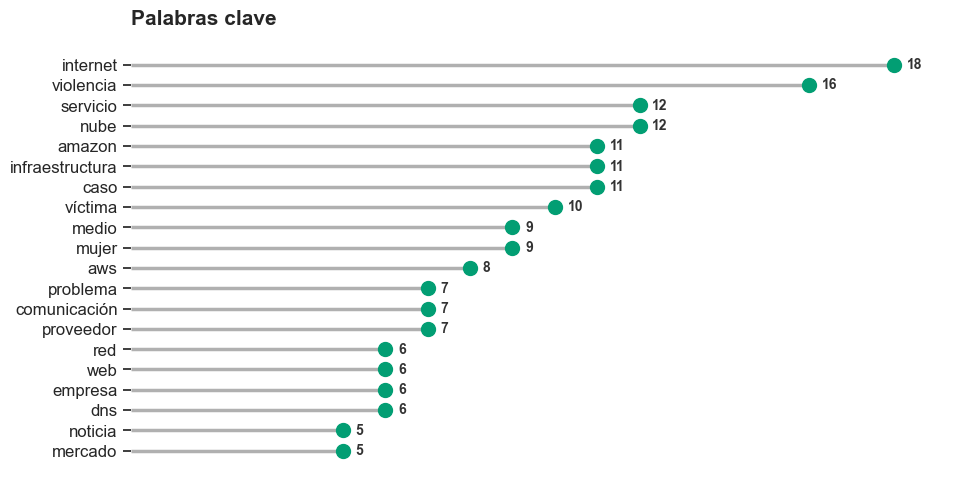

In [53]:
visualizar_palabras_clave_lollipop(palabras_clave)

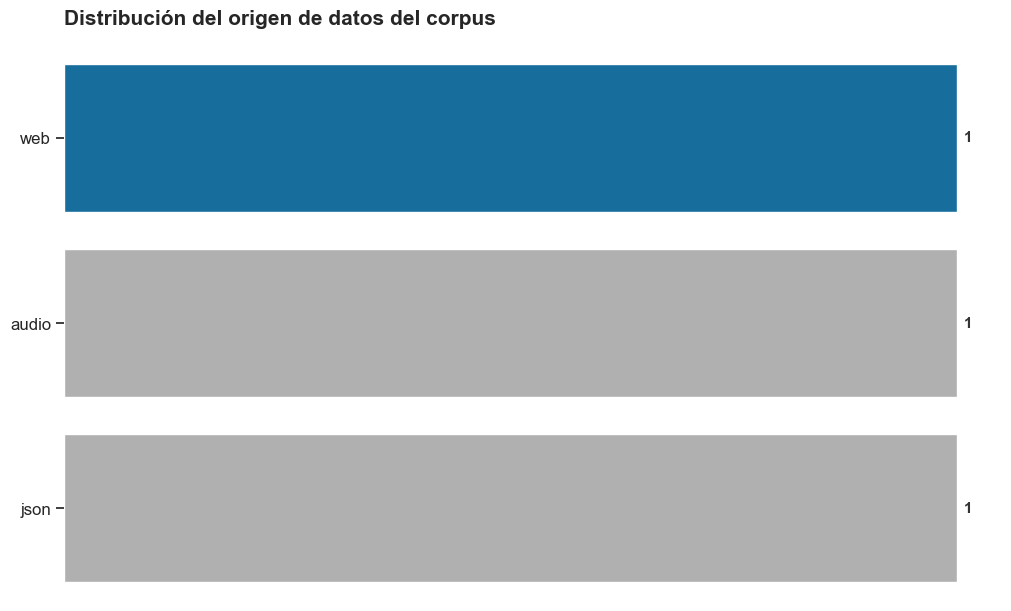

In [46]:
visualizar_origen(df_corpus)

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [ ]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        
        # PASO 2: Instanciá AnalizadorCorpus y derivale el DataFrame resultante para procesar.

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable, deberías dropearla o extraer sus textos antes de guardar.
        
        # PASO 4: Persistí las estadísticas y el diccionario de entidades devueltas por el Analizador como JSON local.
        pass

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="...")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()

> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [ ]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    
    with gr.Tab("Panorama y Métricas"):
        # Incluí acá la visualización de frecuencias y orígenes, acompañando un gr.DataFrame con métricas generales.
        pass
        
    with gr.Tab("Explorador de Entidades"):
        # Desarrollá un textbox para ingresar una entidad y un botón que dispare
        # un filtrado, mostrando sólo las oraciones dentro de los textos donde se mencionó dicha entidad.
        pass

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.